In [ ]:
  import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, roc_curve, auc

import tensorflow as tf
import keras
from keras import Sequential
from keras import layers
from keras import utils
from keras import optimizers

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/MU projekat/Modeli/Neuralna mreza/creditscore_dataset.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98438 entries, 0 to 98437
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     98438 non-null  object 
 1   Occupation                91511 non-null  object 
 2   Annual_Income             98438 non-null  float64
 3   Num_Bank_Accounts         98438 non-null  int64  
 4   Num_Credit_Card           98438 non-null  float64
 5   Interest_Rate             98438 non-null  float64
 6   Num_of_Loan               98438 non-null  float64
 7   Delay_from_due_date       98438 non-null  int64  
 8   Num_of_Delayed_Payment    98438 non-null  float64
 9   Changed_Credit_Limit      98438 non-null  float64
 10  Num_Credit_Inquiries      98438 non-null  float64
 11  Credit_Mix                98438 non-null  object 
 12  Outstanding_Debt          98438 non-null  float64
 13  Credit_Utilization_Ratio  98438 non-null  float64
 14  Credit

In [ ]:
data['Occupation'] = data['Occupation'].fillna(data['Occupation'].mode()[0])
data['Amount_invested_monthly'] = data['Amount_invested_monthly'].fillna(data['Amount_invested_monthly'].median())

Credit_Score
Standard    52363
Poor        28518
Good        17557
Name: count, dtype: int64


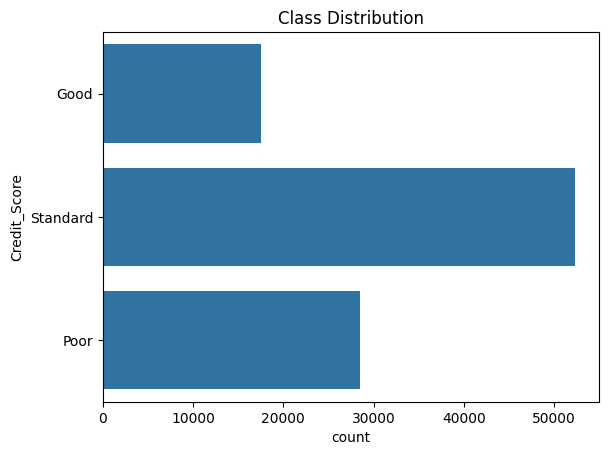

In [ ]:
print(data['Credit_Score'].value_counts())

sns.countplot(data['Credit_Score'])
plt.title('Class Distribution')
plt.show()

Transformacija ciljne varijable 'Credir_Score' u numeričke vrijednosti

In [ ]:
label_encoder = LabelEncoder()
data['Credit_Score'] = label_encoder.fit_transform(data['Credit_Score'])

In [ ]:
print(label_encoder.classes_)

['Good' 'Poor' 'Standard']


Transformacija preostalih kategoričkih varijabli

In [ ]:
categorical_columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98438 entries, 0 to 98437
Data columns (total 56 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Annual_Income                                       98438 non-null  float64
 1   Num_Bank_Accounts                                   98438 non-null  int64  
 2   Num_Credit_Card                                     98438 non-null  float64
 3   Interest_Rate                                       98438 non-null  float64
 4   Num_of_Loan                                         98438 non-null  float64
 5   Delay_from_due_date                                 98438 non-null  int64  
 6   Num_of_Delayed_Payment                              98438 non-null  float64
 7   Changed_Credit_Limit                                98438 non-null  float64
 8   Num_Credit_Inquiries                                98438 non-null  float64


Izdvajanje ulaznih varijabli i definisanje izlazne varijable

In [ ]:
X = data.drop(columns=['Credit_Score'])
y = data['Credit_Score']

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Holdout metoda, 70% za treniranje, 15 % za validaciju, 15% za testiranje

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
num_classes = len(np.unique(y))
y_train = utils.to_categorical(y_train, num_classes)
y_val = utils.to_categorical(y_val, num_classes)
y_test = utils.to_categorical(y_test, num_classes)

In [ ]:
model = Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
optimizer = optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history1 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=16, verbose=1)

Epoch 1/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.6205 - loss: 0.8014 - val_accuracy: 0.6762 - val_loss: 0.7103
Epoch 2/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.6670 - loss: 0.7157 - val_accuracy: 0.6780 - val_loss: 0.6904
Epoch 3/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6746 - loss: 0.7008 - val_accuracy: 0.6791 - val_loss: 0.6859
Epoch 4/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6832 - loss: 0.6869 - val_accuracy: 0.6833 - val_loss: 0.6851
Epoch 5/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.6832 - loss: 0.6846 - val_accuracy: 0.6875 - val_loss: 0.6742
Epoch 6/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.6854 - loss: 0.6800 - val_accuracy: 0.6909 - val_loss: 0.6729
Epoch 7/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.6870 - loss: 0.6752 - val_accuracy: 0.6895 - val_loss: 0.6715
Epoch 8/20
4307/4307 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.6865 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7005 - loss: 0.6553


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


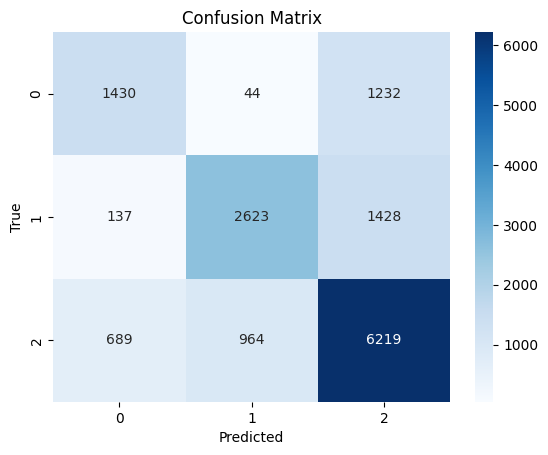

              precision    recall  f1-score   support

           0       0.63      0.53      0.58      2706
           1       0.72      0.63      0.67      4188
           2       0.70      0.79      0.74      7872

    accuracy                           0.70     14766
   macro avg       0.69      0.65      0.66     14766
weighted avg       0.69      0.70      0.69     14766

Cohen's Kappa: 0.4767838787275078


In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_true, y_pred_classes)
print(report)

kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"Cohen's Kappa: {kappa}")

In [ ]:
history2 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, verbose=1)

Epoch 1/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7029 - loss: 0.6367 - val_accuracy: 0.6989 - val_loss: 0.6533
Epoch 2/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7018 - loss: 0.6355 - val_accuracy: 0.6999 - val_loss: 0.6516
Epoch 3/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7030 - loss: 0.6325 - val_accuracy: 0.6962 - val_loss: 0.6558
Epoch 4/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7048 - loss: 0.6312 - val_accuracy: 0.6991 - val_loss: 0.6530
Epoch 5/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7022 - loss: 0.6324 - val_accuracy: 0.7003 - val_loss: 0.6491
Epoch 6/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7025 - loss: 0.6313 - val_accuracy: 0.7023 - val_loss: 0.6523
Epoch 7/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7070 - loss: 0.6273 - val_accuracy: 0.6998 - val_loss: 0.6492
Epoch 8/30
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7072 - loss: 0.6265 - 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7070 - loss: 0.6359


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


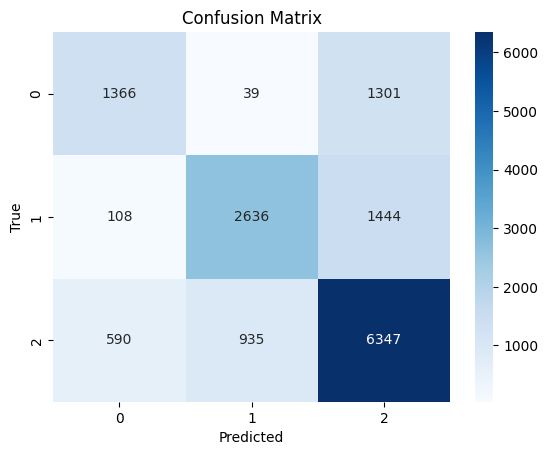

              precision    recall  f1-score   support

           0       0.66      0.50      0.57      2706
           1       0.73      0.63      0.68      4188
           2       0.70      0.81      0.75      7872

    accuracy                           0.70     14766
   macro avg       0.70      0.65      0.67     14766
weighted avg       0.70      0.70      0.70     14766

Cohen's Kappa: 0.48137632946303155


In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_true, y_pred_classes)
print(report)

kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"Cohen's Kappa: {kappa}")

In [ ]:
history3 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7141 - loss: 0.6088 - val_accuracy: 0.7071 - val_loss: 0.6401
Epoch 2/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7172 - loss: 0.6050 - val_accuracy: 0.7074 - val_loss: 0.6414
Epoch 3/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7167 - loss: 0.6065 - val_accuracy: 0.7057 - val_loss: 0.6414
Epoch 4/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7176 - loss: 0.6032 - val_accuracy: 0.7049 - val_loss: 0.6412
Epoch 5/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7167 - loss: 0.6044 - val_accuracy: 0.7040 - val_loss: 0.6417
Epoch 6/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7203 - loss: 0.5995 - val_accuracy: 0.7045 - val_loss: 0.6431
Epoch 7/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7131 - loss: 0.6072 - val_accuracy: 0.7028 - val_loss: 0.6437
Epoch 8/100
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7169 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7118 - loss: 0.6347


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


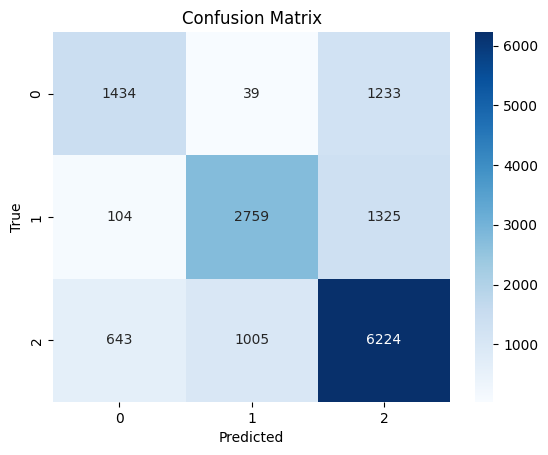

              precision    recall  f1-score   support

           0       0.66      0.53      0.59      2706
           1       0.73      0.66      0.69      4188
           2       0.71      0.79      0.75      7872

    accuracy                           0.71     14766
   macro avg       0.70      0.66      0.67     14766
weighted avg       0.70      0.71      0.70     14766

Cohen's Kappa: 0.4946465645690732


In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_true, y_pred_classes)
print(report)

kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"Cohen's Kappa: {kappa}")

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [ ]:
print("After SMOTE:")
print(pd.Series(y_balanced).value_counts())

After SMOTE:
Credit_Score
0    52363
2    52363
1    52363
Name: count, dtype: int64


In [ ]:
X_balanced = scaler.fit_transform(X_balanced)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
num_classes = len(np.unique(y))
y_train = utils.to_categorical(y_train, num_classes)
y_val = utils.to_categorical(y_val, num_classes)
y_test = utils.to_categorical(y_test, num_classes)

In [ ]:
history4 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6760 - loss: 0.7361 - val_accuracy: 0.7478 - val_loss: 0.5683
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7379 - loss: 0.5865 - val_accuracy: 0.7565 - val_loss: 0.5427
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7463 - loss: 0.5604 - val_accuracy: 0.7588 - val_loss: 0.5311
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7491 - loss: 0.5499 - val_accuracy: 0.7640 - val_loss: 0.5243
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7583 - loss: 0.5406 - val_accuracy: 0.7665 - val_loss: 0.5181
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7606 - loss: 0.5353 - val_accuracy: 0.7692 - val_loss: 0.5129
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7611 - loss: 0.5287 - val_accuracy: 0.7712 - val_loss: 0.5101
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7635 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7893 - loss: 0.4659


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

737/737 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


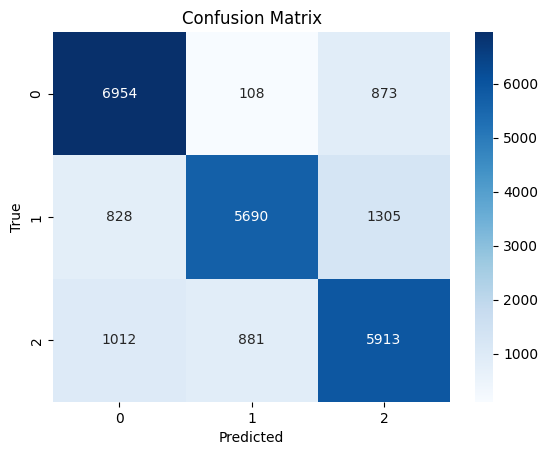

              precision    recall  f1-score   support

           0       0.79      0.88      0.83      7935
           1       0.85      0.73      0.78      7823
           2       0.73      0.76      0.74      7806

    accuracy                           0.79     23564
   macro avg       0.79      0.79      0.79     23564
weighted avg       0.79      0.79      0.79     23564

Cohen's Kappa: 0.681185131356445


In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_true, y_pred_classes)
print(report)

kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"Cohen's Kappa: {kappa}")